 ## Master in Artificial Intelligence, USC, UDC, UVigo. 2025/2026
## COMPUTER VISION I
## Lab 6: Feature Matching with SIFT

## Introduction to SIFT

Feature matching refers to the process of finding corresponding keypoints between two images of the same scene or object. The **Scale-Invariant Feature Transform (SIFT)** algorithm is one of the most robust methods for detecting and describing local features in images.

SIFT keypoints are distinctive image features such as corners, edges, and blobs that can be reliably identified across different:
- Scales (zoom levels)
- Rotations
- Illumination changes
- Viewpoint variations (within limits)

### SIFT Algorithm Pipeline

1. **Scale-space extrema detection**: Build a Gaussian pyramid and Difference of Gaussians (DoG), then find local extrema
2. **Keypoint localization**: Refine keypoint locations and filter unstable points
3. **Orientation assignment**: Compute dominant gradient orientation for rotation invariance
4. **Descriptor extraction**: Create 128-dimensional feature vector describing local image structure

![SIFT](sift.png)

## Setup

Import required libraries and visualization utilities.

In [1]:
import cv2
from cv2 import GaussianBlur,resize, INTER_NEAREST
from matplotlib import pyplot as plt
import numpy as np

# Import visualization utilities
from lab6_utils import (
    plot_gaussian_pyramid,
    visualize_all_dog_levels,
    visualize_keypoints,
    visualize_keypoints_with_orientation,
    compare_matching_with_opencv,
    descriptor_exercise_with_gradients,
    apply_rotation, apply_scale, apply_brightness,
    apply_noise, apply_blur,
    visualize_transformations_custom,
    test_sift_robustness_with_opencv_custom
)

# Load test image
building = cv2.imread('building-600by600.tif', cv2.IMREAD_GRAYSCALE)

print(f"Loaded image: {building.shape}")

Loaded image: (600, 600)


In [2]:
def computeHistogram(magnitude, orientation, x, y, radius, num_bins, reference_angle=0):
    """
    Build histogram of gradient orientations in a window.
    
    Args:
        magnitude: Gradient magnitude image
        orientation: Gradient orientation image (degrees)
        x, y: Center point coordinates
        radius: Window radius in pixels
        num_bins: Number of orientation bins (typically 36 or 8)
        reference_angle: Angle to subtract from all orientations (for rotation invariance)
    
    Returns:
        np.array: Histogram of length num_bins
    """
    hist = np.zeros(num_bins)
    bin_size = 360.0 / num_bins

    r = int(radius)
    x, y = int(x), int(y)

    for di in range(-r, r + 1):
        for dj in range(-r, r + 1):
            py, px = y + di, x + dj
            if 0 <= py < magnitude.shape[0] and 0 <= px < magnitude.shape[1]:
                mag = magnitude[py, px]
                angle = (orientation[py, px] - reference_angle) % 360
                bin_idx = int(angle / bin_size) % num_bins
                hist[bin_idx] += mag
    
    return hist

---
## Gaussian Pyramid Construction

### Background: Scale-Space Representation

To detect features at multiple scales, SIFT builds a **scale-space pyramid**:

- **Octaves**: Different image sizes (each octave is half the size of the previous)
- **Scales**: Different blur levels within each octave

The Gaussian kernel sigma values follow: σ, σ·k, σ·k², σ·k³, ... where k = 2^(1/num_intervals)

Between octaves, we downsample by 2 and the effective sigma doubles.

### Question 1: Generate Gaussian Kernels (0.05 points)

Implement a function to generate the sigma values for each scale level within an octave.

**Requirements:**
- Generate `num_intervals + 3` sigma values (we need extra scales for DoG computation)
- Use the formula: σ_i = σ * k^i where k = 2^(1/num_intervals)
- Return a list of sigma values

In [3]:
def generateGaussianKernels(sigma=0.5, num_intervals=3):
    """
    Generate sigma values for Gaussian blur at each scale.
    
    Args:
        sigma: Base sigma value for the first scale
        num_intervals: Number of intervals per octave (typically 3)
    
    Returns:
        list: Sigma values for each scale [σ₀, σ₁, σ₂, ..., σₙ]
              Length should be num_intervals + 3
    """
    # Calculate the geometric step k
    k = 2 ** (1.0 / num_intervals)
    
    kernels = []
    # We need num_intervals + 3 scales
    for i in range(num_intervals + 3):
        # Apply formula: sigma_i = sigma * k^i
        sigma_i = sigma * (k ** i)
        kernels.append(sigma_i)
        
    return kernels

# Test your implementation
kernels = generateGaussianKernels()
print(f"Generated {len(kernels)} kernels: {[f'{k:.3f}' for k in kernels]}")

Generated 6 kernels: ['0.500', '0.630', '0.794', '1.000', '1.260', '1.587']


#### Validation Checkpoint 1

Run these checks to verify your implementation:

In [4]:
# Validation for Question 1
test_kernels = generateGaussianKernels(sigma=1.0, num_intervals=3)

assert len(test_kernels) == 6, f"Expected 6 kernels, got {len(test_kernels)}"
assert abs(test_kernels[0] - 1.0) < 0.01, "First kernel should be sigma=1.0"
assert abs(test_kernels[3] / test_kernels[0] - 2.0) < 0.01, "Sigma should double after 3 intervals"

print("Question 1 validation passed!")
print(f"  Kernels correctly spaced: {test_kernels[1]/test_kernels[0]:.3f} (should be ~1.26 = 2^(1/3))")

Question 1 validation passed!
  Kernels correctly spaced: 1.260 (should be ~1.26 = 2^(1/3))


---
### Question 2: Generate Gaussian Pyramid (0.12 points)

Build the complete Gaussian pyramid by applying blur at each scale and downsampling between octaves.

**Requirements:**
- For each octave, apply Gaussian blur with each sigma from `gaussian_kernels`
- After processing all scales in an octave, downsample the image by 2x for the next octave
- Use `cv2.GaussianBlur()` with `sigmaX=sigma, sigmaY=sigma`
- Use `cv2.resize()` with `INTER_NEAREST` for downsampling
- Return a nested list: `gaussian_images[octave][scale]`

In [5]:
def generateGaussianImages(image, gaussian_kernels, num_octaves=4):
    """
    Generate multiscale Gaussian pyramid.
    
    Args:
        image: Input grayscale image
        gaussian_kernels: List of sigma values from generateGaussianKernels()
        num_octaves: Number of octaves to generate
    
    Returns:
        np.array: Nested array gaussian_images[octave][scale]
                  Shape: (num_octaves, num_scales)
    """
    gaussian_images = []
    
    for octave_index in range(num_octaves):
        gaussian_images_in_octave = []
        
        # Start with the base image for this octave
        # Ideally, we should pre-blur the first image to match gaussian_kernels[0],
        # but for simplicity in this lab we assume the base image starts at that level 
        # or we just take the first blur.
        
        # First image in the stack: apply the base sigma (gaussian_kernels[0])
        # Note: In a rigorous implementation, we assume input image has sigma=0.5 
        # and we blur to reach gaussian_kernels[0]. Here, we just blur directly.
        current_image = GaussianBlur(image, (0, 0), sigmaX=gaussian_kernels[0], sigmaY=gaussian_kernels[0])
        gaussian_images_in_octave.append(current_image)
        
        # Track the current effective sigma
        previous_sigma = gaussian_kernels[0]
        
        # Apply incremental blur to reach each target sigma
        for target_sigma in gaussian_kernels[1:]:
            # Calculate incremental sigma to avoid cumulative blur bug
            # Theory: Convolution of two Gaussians produces another Gaussian
            #         G(σ₁) ⊗ G(σ₂) = G(√(σ₁² + σ₂²))
            # 
            # We have effective blur previous_sigma, we want target_sigma.
            # So: target_sigma^2 = previous_sigma^2 + sigma_diff^2
            
            sigma_diff = np.sqrt(target_sigma**2 - previous_sigma**2)
            
            # Apply only the incremental blur
            current_image = GaussianBlur(current_image, (0, 0), sigmaX=sigma_diff, sigmaY=sigma_diff)
            gaussian_images_in_octave.append(current_image)
            
            # Update the current effective sigma
            previous_sigma = target_sigma
        
        gaussian_images.append(gaussian_images_in_octave)
        
        # Downsample for next octave
        # We usually pick the image with 2*sigma relative to base to downsample,
        # which corresponds roughly to the one at index -3 in standard SIFT 
        # (since we generate num_intervals+3 images).
        octave_base = gaussian_images_in_octave[-3]
        
        image = resize(octave_base, (int(octave_base.shape[1] / 2), int(octave_base.shape[0] / 2)), 
                      interpolation=INTER_NEAREST)
    
    return np.array(gaussian_images, dtype=object)

# Test your implementation
images = generateGaussianImages(building, kernels, num_octaves=4)
print(f"Generated pyramid with {len(images)} octaves")
print(f"Octave 0: {len(images[0])} scales, image shape: {images[0][0].shape}")
print(f"Octave 1: {len(images[1])} scales, image shape: {images[1][0].shape}")

Generated pyramid with 4 octaves
Octave 0: 6 scales, image shape: (600, 600)
Octave 1: 6 scales, image shape: (300, 300)


#### Validation Checkpoint 2

In [6]:
# Validation for Question 2
assert len(images) == 4, f"Expected 4 octaves, got {len(images)}"
assert len(images[0]) == 6, f"Expected 6 scales per octave, got {len(images[0])}"

h0, w0 = images[0][0].shape
h1, w1 = images[1][0].shape
assert abs(h1 - h0/2) < 2, f"Octave 1 should be half size of octave 0"

# Check that blurring increases
diff_01 = np.abs(images[0][0] - images[0][1]).mean()
diff_02 = np.abs(images[0][0] - images[0][2]).mean()
assert diff_02 > diff_01, "More blur should create bigger difference"

print("Question 2 validation passed!")
print(f"  Pyramid sizes: {[images[i][0].shape for i in range(len(images))]}")

Question 2 validation passed!
  Pyramid sizes: [(600, 600), (300, 300), (150, 150), (75, 75)]


#### Visualization: Gaussian Pyramid

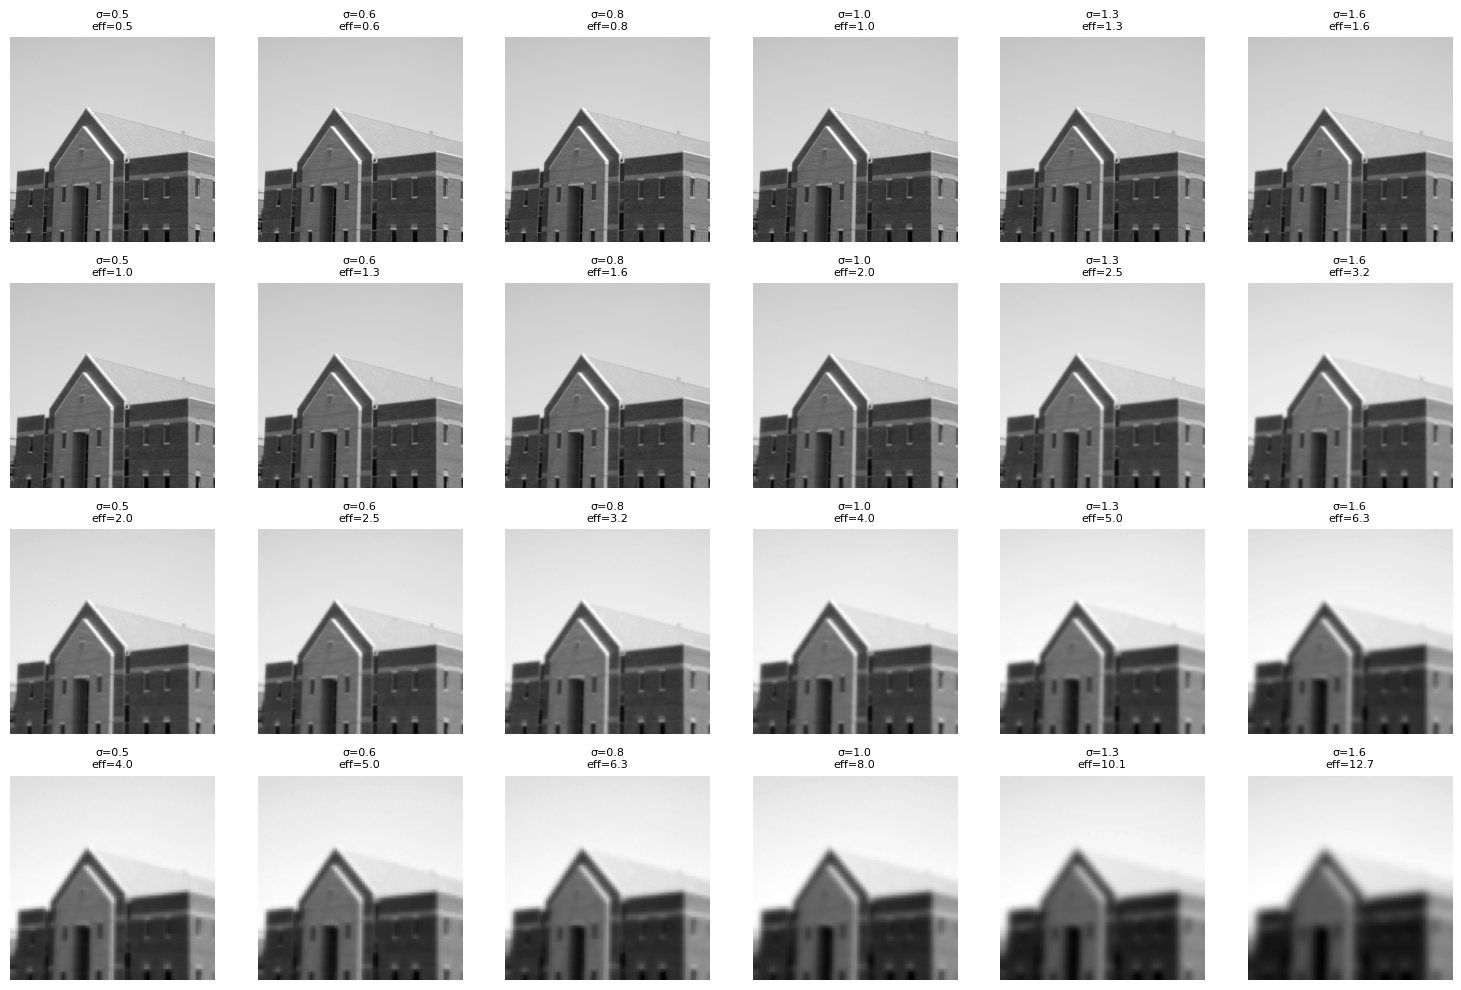

In [7]:
# Visualize your Gaussian pyramid
plot_gaussian_pyramid(images)

---
## Difference of Gaussians

### Background: DoG as LoG Approximation

The **Difference of Gaussians (DoG)** approximates the Laplacian of Gaussian (LoG), which is excellent for blob detection:

$$\text{DoG}(x,y,\sigma) = G(x,y,k\sigma) - G(x,y,\sigma) \approx (k-1)\sigma^2 \nabla^2 G$$

This acts as a **band-pass filter** that highlights structures at specific scales.

### Question 3: Compute Difference of Gaussians (0.06 points)

Compute DoG images by subtracting consecutive scales within each octave.

**Requirements:**
- For each octave, compute DoG[i] = Gaussian[i+1] - Gaussian[i]
- Convert images to float32 before subtraction to avoid overflow
- Return nested array of DoG images

In [8]:
def dog_levels(gaussian_images):
    """
    Compute Difference of Gaussians for all octaves.
    
    Args:
        gaussian_images: Output from generateGaussianImages()
                        gaussian_images[octave][scale]
    
    Returns:
        np.array: DoG images, shape (num_octaves, num_scales-1)
                  dog_images[octave][scale] = G[octave][scale+1] - G[octave][scale]
    """
    dog_images = []
    
    for octave_idx in range(len(gaussian_images)):
        gaussian_images_in_octave = gaussian_images[octave_idx]
        dog_images_in_octave = []
        
        # Iterate through scales up to len-1 (since we need pairs)
        for i in range(len(gaussian_images_in_octave) - 1):
            # Convert to float32 to allow negative values during subtraction
            img1 = gaussian_images_in_octave[i].astype(np.float32)
            img2 = gaussian_images_in_octave[i+1].astype(np.float32)
            
            # Compute difference: Next scale - Current scale
            dog = img2 - img1
            dog_images_in_octave.append(dog)
            
        dog_images.append(dog_images_in_octave)
    
    # Return as object array because octaves have different sizes (shapes)
    return np.array(dog_images, dtype=object)

# Test your implementation
dogs = dog_levels(images)
print(f"Generated DoG pyramid with {len(dogs)} octaves")
print(f"Each octave has {len(dogs[0])} DoG images")
print(f"DoG value range: [{dogs[0][0].min():.1f}, {dogs[0][0].max():.1f}]")

Generated DoG pyramid with 4 octaves
Each octave has 5 DoG images
DoG value range: [-6.0, 6.0]


#### Validation Checkpoint 3

In [9]:
# Validation for Question 3
assert len(dogs) == 4, f"Expected 4 octaves, got {len(dogs)}"
assert len(dogs[0]) == 5, f"Expected 5 DoG images per octave (6 Gaussian - 1), got {len(dogs[0])}"

# Check that DoG contains both positive and negative values
assert dogs[0][0].min() < 0, "DoG should have negative values"
assert dogs[0][0].max() > 0, "DoG should have positive values"

# Check data type
assert dogs[0][0].dtype in [np.float32, np.float64], "DoG should be floating point"

print("Question 3 validation passed!")
print(f"  DoG shapes: {[dogs[i][0].shape for i in range(len(dogs))]}")

Question 3 validation passed!
  DoG shapes: [(600, 600), (300, 300), (150, 150), (75, 75)]


#### Visualization: DoG Pyramid

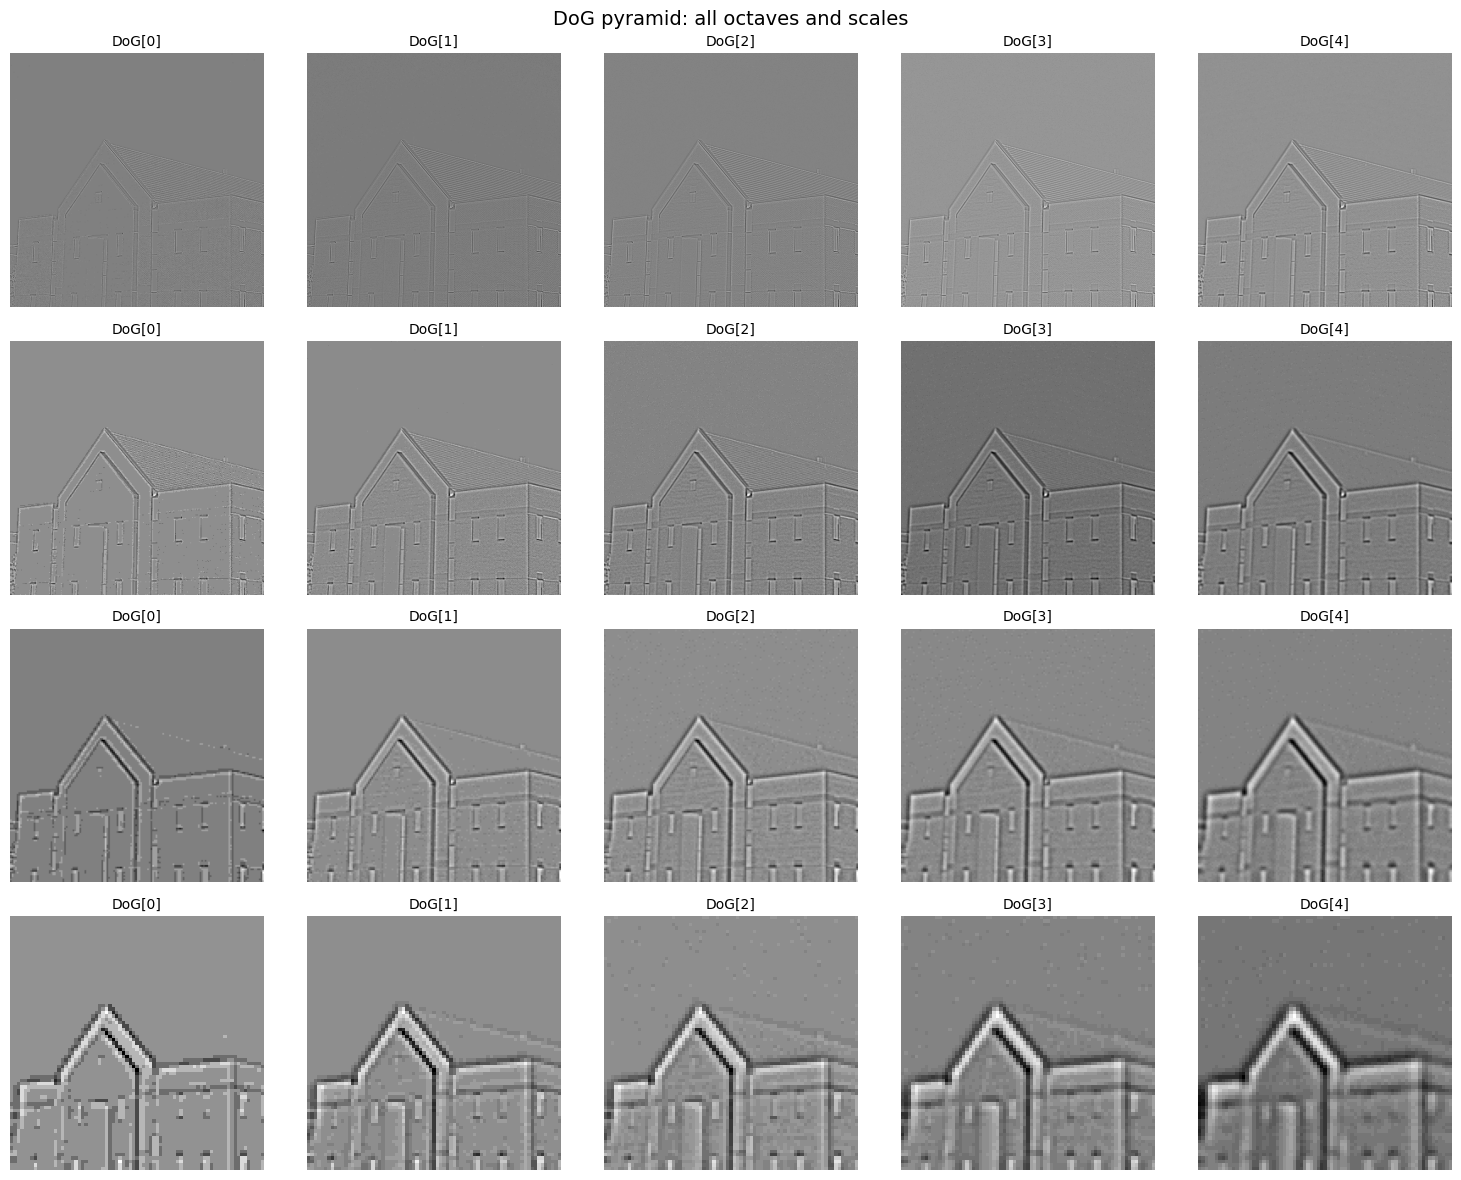

In [10]:
# Visualize DoG pyramid
visualize_all_dog_levels(dogs)

---
## Scale-Space Extrema Detection

### Background: 3D Extrema Detection

A keypoint is a point that is a **local maximum or minimum** in a 3×3×3 neighborhood:

```
Scale σ+1:    □ □ □
              □ □ □
              □ □ □

Scale σ:      □ □ □
              □ ● □    ← Check if ● is max/min of ALL 26 neighbors
              □ □ □

Scale σ-1:    □ □ □
              □ □ □
              □ □ □
```

**Why 26 neighbors?** 8 in current scale + 9 above + 9 below = 26

**Why skip first and last DoG?** We need a DoG image above and below to check extrema.

### Question 4: Find Scale-Space Extrema (0.10 points)

Detect keypoints as 3D local extrema in the DoG pyramid.

**Requirements:**
- For each octave, check DoG scales 1 through len(dog_octave)-2 (skip first and last)
- For each pixel (i, j), extract 3×3×3 cube of values
- Check if center pixel is maximum OR minimum of all 27 values in cube
- Apply contrast threshold: `abs(center_value) >= threshold`
- Skip pixels near image borders (distance < `border`)
- Scale coordinates back to original image size: multiply by 2^octave
- Return list of tuples: (x, y, octave, scale)

In [11]:
def findScaleSpaceExtrema(dog_images, threshold=5, border=5):
    """
    Find keypoints as 3D extrema in scale-space.
    
    Args:
        dog_images: DoG pyramid from dog_levels()
        threshold: Minimum absolute contrast to be considered a keypoint
        border: Pixels to skip at image edges
    
    Returns:
        list: Keypoints as (x, y, octave_idx, scale_idx) tuples
              Coordinates (x, y) are in original image space
    """
    keypoints = []

    for octave_idx, dog_octave in enumerate(dog_images):
        # We need 3 consecutive DoG images, so skip first and last
        for scale_idx in range(1, len(dog_octave) - 1):
            prev_img = dog_octave[scale_idx - 1]
            curr_img = dog_octave[scale_idx]
            next_img = dog_octave[scale_idx + 1]

            # Check each pixel (skip borders)
            # Optimization: could be vectorised, but loops are clearer for learning
            for i in range(border, curr_img.shape[0] - border):
                for j in range(border, curr_img.shape[1] - border):

                    # Get center pixel value
                    center = curr_img[i, j]

                    # Skip low contrast
                    if abs(center) < threshold:
                        continue

                    # Extract 3x3x3 neighborhood
                    # Neighbors in current scale
                    curr_window = curr_img[i-1:i+2, j-1:j+2]
                    # Neighbors in previous scale
                    prev_window = prev_img[i-1:i+2, j-1:j+2]
                    # Neighbors in next scale
                    next_window = next_img[i-1:i+2, j-1:j+2]
                    
                    # Stack them to form a cube
                    cube = np.array([prev_window, curr_window, next_window])

                    # Check if center is maximum or minimum of all 27 values
                    # Note: We compare center against the max/min of the cube.
                    # Ideally, we should exclude the center itself from the comparison,
                    # but checking strict inequality (> or <) usually handles it,
                    # or checking if it equals the global max/min of the cube.
                    
                    if center == cube.max() or center == cube.min():
                        # Calculate coordinates in original image space
                        # Octave 0 is size 1, Octave 1 is size 0.5 (so coord * 2), etc.
                        scale_factor = 2 ** octave_idx
                        
                        # j is x (column), i is y (row)
                        x = j * scale_factor
                        y = i * scale_factor
                        
                        keypoints.append((x, y, octave_idx, scale_idx))

    return keypoints

# Test your implementation
keypoints = findScaleSpaceExtrema(dogs, threshold=10)
print(f"Found {len(keypoints)} keypoints")
if len(keypoints) > 0:
    print(f"First keypoint: x={keypoints[0][0]}, y={keypoints[0][1]}, octave={keypoints[0][2]}, scale={keypoints[0][3]}")

Found 791 keypoints
First keypoint: x=223, y=207, octave=0, scale=2


#### Validation Checkpoint 4

In [12]:
# Validation for Question 4
assert len(keypoints) > 100, f"Expected many keypoints, got only {len(keypoints)}"
assert len(keypoints) < 10000, f"Too many keypoints ({len(keypoints)}), check threshold"

# Check keypoint format
x, y, o, s = keypoints[0]
assert 0 <= x < building.shape[1], "X coordinate out of bounds"
assert 0 <= y < building.shape[0], "Y coordinate out of bounds"
assert 0 <= o < 4, "Octave index out of range"
assert 1 <= s <= 3, "Scale index should be in middle range (not first or last DoG)"

print("Question 4 validation passed!")
print(f"  Keypoint distribution by octave: {[sum(1 for kp in keypoints if kp[2] == i) for i in range(4)]}")

Question 4 validation passed!
  Keypoint distribution by octave: [634, 103, 39, 15]


#### Visualization: Detected Keypoints

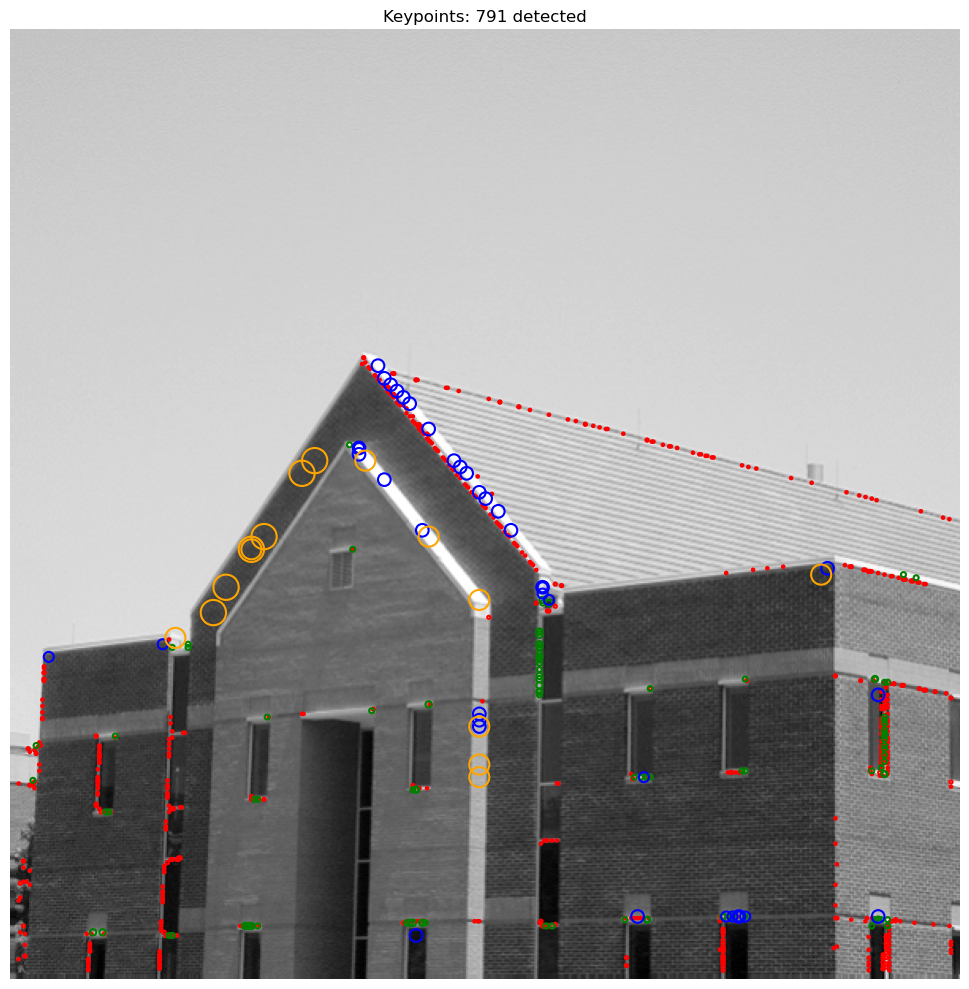

In [13]:
# Visualize keypoints on original image
visualize_keypoints(building, keypoints)

---
## Orientation Assignment

### Background: Rotation Invariance

To make SIFT rotation-invariant, we:
1. Compute image gradients (magnitude and direction)
2. Build a histogram of gradient orientations around each keypoint
3. Assign the dominant orientation as the keypoint's canonical orientation

Later, when computing descriptors, we'll rotate the sampling grid to align with this orientation.

### Question 5: Compute Image Gradients (0.05 points)

Compute gradient magnitude and orientation using Sobel operators.

**Requirements:**
- Use `cv2.Sobel()` to compute dx and dy derivatives
- Magnitude: `sqrt(dx² + dy²)`
- Orientation: `arctan2(dy, dx)` converted to degrees in range [0, 360)

In [14]:
def computeGradients(image):
    """
    Compute gradient magnitude and orientation for the entire image.
    
    Args:
        image: Grayscale image
    
    Returns:
        tuple: (magnitude, orientation)
               magnitude: Same shape as image, dtype float
               orientation: Same shape as image, values in [0, 360) degrees
    """
    # Calculate gradients in x and y direction using Sobel
    # ksize=3 is a standard kernel size, CV_64F handles negative values
    dx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    dy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    
    # Calculate magnitude: sqrt(dx^2 + dy^2)
    magnitude = np.sqrt(dx**2 + dy**2)
    
    # Calculate orientation in radians: arctan2(dy, dx)
    orientation_rad = np.arctan2(dy, dx)
    
    # Convert to degrees
    orientation_deg = np.degrees(orientation_rad)
    
    # Normalize to [0, 360) range
    # modulo operator handles negative angles correctly (e.g., -90 % 360 = 270)
    orientation = orientation_deg % 360
    
    return magnitude, orientation

# Test on a sample image
mag, ori = computeGradients(building)
print(f"Gradient magnitude range: [{mag.min():.1f}, {mag.max():.1f}]")
print(f"Gradient orientation range: [{ori.min():.1f}, {ori.max():.1f}]")

Gradient magnitude range: [0.0, 908.2]
Gradient orientation range: [0.0, 359.9]


#### Validation Checkpoint 5

In [15]:
# Validation for Question 5
assert mag.shape == building.shape, "Magnitude should have same shape as input"
assert ori.shape == building.shape, "Orientation should have same shape as input"
assert mag.min() >= 0, "Magnitude should be non-negative"
assert 0 <= ori.min() and ori.max() < 360, "Orientation should be in [0, 360)"

# Test on a simple gradient
test_img = np.zeros((100, 100), dtype=np.float32)
test_img[:, 50:] = 255  # Vertical edge
test_mag, test_ori = computeGradients(test_img)
edge_ori = test_ori[50, 50]
assert 350 <= edge_ori or edge_ori <= 10, f"Vertical edge should have ~0° orientation, got {edge_ori:.1f}"

print("Question 5 validation passed!")

Question 5 validation passed!


### Question 6: Compute Dominant Orientation (0.05 points)

Compute the dominant orientation for a keypoint by finding the peak in the orientation histogram.

**Requirements:**
- Use `computeHistogram` to build a 36-bin orientation histogram around the keypoint
- Find the bin with maximum value
- Convert bin index to angle (bin_index × 10°)
- Return the dominant orientation in degrees [0, 360)

In [16]:
def computeOrientation(magnitude, orientation, x, y, radius):
    """
    Compute dominant orientation for a keypoint.
    
    Args:
        magnitude: Gradient magnitude image
        orientation: Gradient orientation image
        x, y: Keypoint coordinates
        radius: Window radius (typically sigma * 3)
    
    Returns:
        float: Dominant orientation in degrees [0, 360)
    """
    # 1. Build a 36-bin histogram (covering 360 degrees, so 10 degrees per bin)
    # We use reference_angle=0 because we are finding the absolute dominant angle
    hist = computeHistogram(magnitude, orientation, x, y, radius, num_bins=36, reference_angle=0)
    
    # 2. Find the bin index with the maximum value
    max_bin_idx = np.argmax(hist)
    
    # 3. Convert bin index to angle
    # Each bin represents 360 / 36 = 10 degrees
    # We typically take the start of the bin or the center. 
    # The instructions say: bin_index * 10
    dominant_angle = max_bin_idx * 10.0
    
    return dominant_angle

#### Validation Checkpoint 6-7

In [17]:
# Validation for Questions 6-7
test_hist = computeHistogram(mag, ori, 300, 300, radius=20, num_bins=36)
assert len(test_hist) == 36, f"Expected 36 bins, got {len(test_hist)}"
assert test_hist.sum() > 0, "Histogram should have non-zero values"

test_angle = computeOrientation(mag, ori, 300, 300, radius=20)
assert 0 <= test_angle < 360, f"Orientation should be in [0, 360), got {test_angle}"
assert test_angle % 10 == 0, f"With 36 bins, angle should be multiple of 10, got {test_angle}"

print("Questions 6-7 validation passed!")
print(f"  Test orientation at (300, 300): {test_angle}°")

Questions 6-7 validation passed!
  Test orientation at (300, 300): 320.0°


---
## SIFT Descriptor

### Background: Rotation-Invariant Descriptor

The SIFT descriptor is a **128-dimensional vector** (4×4 cells × 8 orientation bins).

**Key insight for rotation invariance:**
1. Rotate the sampling grid by the keypoint's dominant orientation
2. Compute orientations relative to the keypoint angle

This ensures the same descriptor is computed regardless of image rotation.

### Compute SIFT Descriptor

Given your previous functions we will now create the full descritpor, a 128-D descriptor using rotation-aligned sampling.

**What it does:**
- Divides window of size `2r × 2r` into 4×4 = 16 cells
- For each cell, computes 8-bin orientation histogram (relative to keypoint angle)
- **Rotates sampling coordinates** by keypoint angle:
  - `x_rot = cos(θ) * x_rel - sin(θ) * y_rel`
  - `y_rot = sin(θ) * x_rel + cos(θ) * y_rel`
- Concatenates all 16 histograms → 128 values
- Normalizes to unit length
- Returns None if keypoint too close to boundary

In [18]:
def computeDescriptor(magnitude, orientation, x, y, r, keypoint_angle):
    """
    Compute 128-dimensional SIFT descriptor with improved sampling.

    Improvements over basic version:
    - Gaussian weighting based on distance from keypoint center
    - Denser sampling with subpixel positions
    - Trilinear interpolation for distributing contributions
    """
    x, y = int(x), int(y)
    r = int(r)

    # Check bounds with margin
    margin = int(r * 1.5)
    if y - margin < 0 or y + margin >= magnitude.shape[0] or x - margin < 0 or x + margin >= magnitude.shape[1]:
        return None

    num_cells = 4
    num_bins = 8

    # Descriptor window is 2r × 2r, divided into 4×4 cells
    # Each cell is (r/2) × (r/2)
    hist_width = r / 2.0  # Width of each histogram cell

    angle_rad = np.radians(keypoint_angle)
    cos_a = np.cos(angle_rad)
    sin_a = np.sin(angle_rad)

    # Initialize 4×4×8 descriptor array
    desc_array = np.zeros((num_cells, num_cells, num_bins))

    # Gaussian weighting: sigma = descriptor_window_width / 2
    # This weights samples near the keypoint higher
    gauss_sigma = r

    # Sample densely within the descriptor window
    # Use 0.5 pixel steps for better coverage
    sample_range = int(r * 1.4)  # Sample slightly beyond window

    for dy in np.arange(-sample_range, sample_range, 0.5):
        for dx in np.arange(-sample_range, sample_range, 0.5):

            # Rotate sample point by keypoint angle
            dx_rot = cos_a * dx - sin_a * dy
            dy_rot = sin_a * dx + cos_a * dy

            # Absolute pixel position
            px = x + dx_rot
            py = y + dy_rot

            # Check bounds
            px_int, py_int = int(round(px)), int(round(py))
            if px_int < 0 or px_int >= magnitude.shape[1] or py_int < 0 or py_int >= magnitude.shape[0]:
                continue

            # Compute position in descriptor coordinates
            # Normalize to [-2, 2] where each cell is 1 unit
            xf = dx / hist_width + (num_cells / 2.0) - 0.5
            yf = dy / hist_width + (num_cells / 2.0) - 0.5

            # Skip if outside descriptor window
            if xf < -1 or xf >= num_cells or yf < -1 or yf >= num_cells:
                continue

            # Gaussian weight based on distance from keypoint
            dist_sq = dx**2 + dy**2
            weight = np.exp(-dist_sq / (2 * gauss_sigma**2))

            # Get gradient at this position
            mag = magnitude[py_int, px_int]
            ori = (orientation[py_int, px_int] - keypoint_angle) % 360

            # Apply Gaussian weight
            mag_weighted = mag * weight

            # Compute orientation bin (0-7)
            obin = ori / 45.0

            # Trilinear interpolation: distribute contribution to neighboring cells and bins
            xi, yi = int(np.floor(xf)), int(np.floor(yf))
            oi = int(np.floor(obin)) % num_bins

            # Fractional parts for interpolation
            xfrac = xf - xi
            yfrac = yf - yi
            ofrac = obin - int(np.floor(obin))

            # Distribute to 2×2×2 neighboring histogram bins
            for dy_offset in range(2):
                yy = yi + dy_offset
                if yy < 0 or yy >= num_cells:
                    continue
                y_weight = yfrac if dy_offset == 1 else (1 - yfrac)

                for dx_offset in range(2):
                    xx = xi + dx_offset
                    if xx < 0 or xx >= num_cells:
                        continue
                    x_weight = xfrac if dx_offset == 1 else (1 - xfrac)

                    for do_offset in range(2):
                        oo = (oi + do_offset) % num_bins
                        o_weight = ofrac if do_offset == 1 else (1 - ofrac)

                        contribution = mag_weighted * x_weight * y_weight * o_weight
                        desc_array[yy, xx, oo] += contribution

    # Flatten to 128-D vector
    descriptor = desc_array.flatten()

    # Normalize
    norm = np.linalg.norm(descriptor)
    if norm > 0:
        descriptor = descriptor / norm

        # Threshold large values to 0.2 and renormalize (illumination invariance)
        descriptor = np.clip(descriptor, 0, 0.2)
        norm = np.linalg.norm(descriptor)
        if norm > 0:
            descriptor = descriptor / norm

    return descriptor

#### Validation Checkpoint

In [19]:
# Validation for Question 8
test_desc = computeDescriptor(mag, ori, 300, 300, r=20, keypoint_angle=45)

assert test_desc is not None, "Descriptor should not be None for valid keypoint"
assert len(test_desc) == 128, f"Expected 128-D descriptor, got {len(test_desc)}"
assert abs(np.linalg.norm(test_desc) - 1.0) < 0.01, "Descriptor should be normalized"
assert test_desc.min() >= 0, "Descriptor values should be non-negative"

# Test rotation invariance (approximately)
desc_0 = computeDescriptor(mag, ori, 300, 300, r=20, keypoint_angle=0)
desc_45 = computeDescriptor(mag, ori, 300, 300, r=20, keypoint_angle=45)
# Descriptors should be different (different rotation)
diff = np.linalg.norm(desc_0 - desc_45)
assert diff > 0.1, "Descriptors at different angles should be different"

print("Question 8 validation passed!")
print(f"  Descriptor norm: {np.linalg.norm(test_desc):.3f}")
print(f"  Descriptor range: [{test_desc.min():.3f}, {test_desc.max():.3f}]")

Question 8 validation passed!
  Descriptor norm: 1.000
  Descriptor range: [0.000, 0.265]


---
### Question 7: Analyze Descriptor Behavior (0.20 points)

Now that you've implemented the complete SIFT descriptor, let's analyze how gradients and descriptors behave at different image locations.

This exercise demonstrates:
- How gradient orientation relates to image structure
- Why descriptor histograms look different at edges vs corners vs uniform regions
- What information SIFT actually encodes

**Task:** Run the visualization below on a checkerboard pattern and analyze the results.Compare the results with the clean image and the noisy image. What are the differences you visualise.

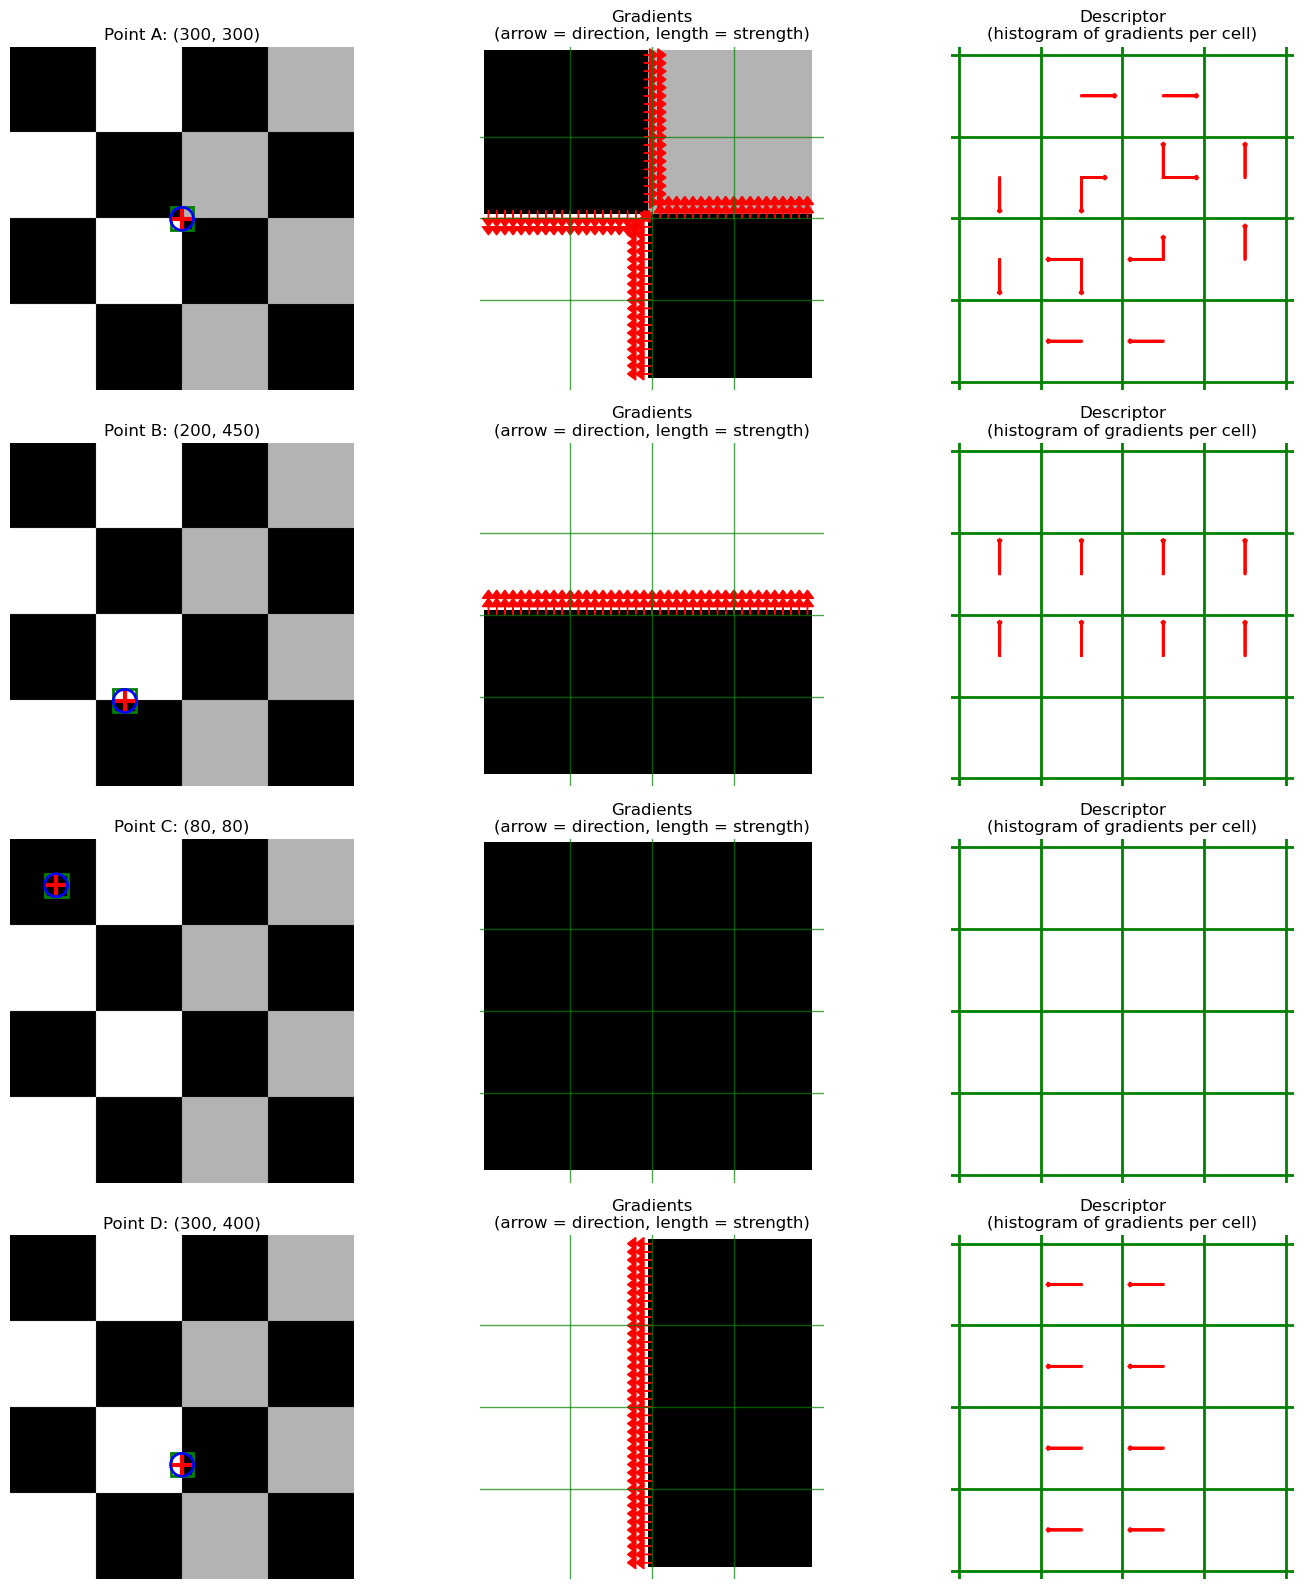

In [20]:
# Load checkerboard image
checkerboard_clean = cv2.imread('checkerboard-clean.tif', cv2.IMREAD_GRAYSCALE)
checkerboard_noisy = cv2.imread('checkerboard-noisy.tif', cv2.IMREAD_GRAYSCALE)
# Visualize gradients and descriptors at 4 different points
descriptor_exercise_with_gradients(checkerboard_clean, computeGradients)

#### Analysis Questions

For each of the 4 points (A, B, C, D) shown above, answer:

**Point A:**
1. What gradient patterns do you observe? (direction and strength)
2. What does the descriptor histogram show? Which orientation bins are strongest?

**Point B:**
1. How do the gradients differ from Point A?
2. Why does the descriptor histogram look this way?

**Point C:**
1. What is special about the gradient pattern here?
2. How is the descriptor different from Points A and B?
3. Would this be a good or bad keypoint? Why?

**Point D:**
1. Compare the gradients to Points A, B, and C
2. What does the descriptor encode about this location?
3. How does rotation invariance work for this point?

**General:**
- Which points would make the best SIFT keypoints? Why?
- What would happen to these descriptors if the image was rotated 45°?
- Why are descriptors computed in a 4×4 grid rather than a single histogram?
- Compared with the noisy version, what are the key differences and why?

### Analysis Questions

Based on the visualization results:

**Point A (Corner - 300, 300):**
* **Gradient Patterns:** Strong gradients are visible in two distinct perpendicular directions. We see a vertical line of arrows pointing right and a horizontal line of arrows pointing up, meeting at the center. This indicates a corner structure where two edges intersect.
* **Descriptor Histogram:** The descriptor shows activity in multiple orientation bins corresponding to the edge directions. Specifically, the 4x4 grid cells show arrows pointing predominantly right ($0^{\circ}$) and up ($90^{\circ}$), capturing the multi-directional nature of the corner.

**Point B (Horizontal Edge - 200, 450):**
* **Gradient Differences:** Unlike Point A, which showed mixed directions, Point B shows gradients pointing in only **one dominant direction** (upwards). This represents a horizontal edge where intensity changes from dark to light moving up.
* **Descriptor Histogram:** The descriptor is highly uniform. Almost all active cells in the grid contain arrows pointing up. This reflects that the local patch contains a single linear structure with no variation along the edge itself.

**Point C (Flat Region - 80, 80):**
* **Gradient Pattern:** The gradient visualization is black/empty, meaning the gradient magnitude is effectively zero. There is no intensity change in this flat region.
* **Descriptor Differences:** The descriptor grid is empty (all bins are zero). Unlike A and B, which encode structure, this descriptor encodes "nothingness."
* **Good or Bad Keypoint?:** This is a **bad keypoint**. Because it lacks distinctiveness and gradients, it cannot be reliably localized or matched against other images.

**Point D (Vertical Edge - 300, 400):**
* **Comparison:** Compared to Point B (upward gradients), Point D shows a uniform column of gradients pointing to the **left**. This distinguishes it as a vertical edge rather than a horizontal one.
* **Descriptor Encoding:** The descriptor encodes a strong, unidirectional feature pointing left.
* **Rotation Invariance:** If the image were rotated, the gradient arrows would point in a new direction. However, SIFT calculates the dominant orientation (the direction of these arrows) and rotates the descriptor grid relative to it. Therefore, the resulting descriptor values would remain approximately the same relative to the keypoint's canonical orientation.

**General Observations:**
* **Best SIFT Keypoints:** **Point A (the corner)** is the best keypoint. Corners have significant intensity changes in all directions, making them unique and precisely localizable ($x, y$).Edges suffer from the aperture problem (hard to localize along the edge), and flat regions have no features.
* **Rotation 45°:** The gradient arrows would rotate by $45^{\circ}$. Since SIFT aligns the descriptor grid to the keypoint's dominant orientation, the histogram bins would shift cyclically, but the relative distribution of the descriptor vector would remain consistent, allowing for matching.
* **4×4 Grid:** Computing a single histogram for the whole patch would lose **spatial information**. We would know *that* gradients exist, but not *where*. The 4x4 grid allows the descriptor to capture the spatial arrangement of the structure (e.g., "gradients are on the left vs. the right"), making it much more distinctive.
* **Noisy vs. Clean:** In a noisy version, Point C (flat) would no longer be empty but would show random, weak gradient arrows (noise). Points A, B, and D would still show their main structure, but the descriptor arrows might jitter slightly due to noise. SIFT handles this by thresholding low-contrast points to ignore regions like C and normalizing the descriptor to be robust against linear illumination changes.

---
## Complete SIFT Implementation

### Integrate Everything

Combine all steps to detect keypoints with orientations and descriptors. This will follow the same steps as your `findScaleSpaceExtrema` but with the `descriptors` and `dominant angle` calculation (there is no question here, if you managed to do `findScaleSpaceExtrema` you just need to update with your solution)

**What it does:**
- Uses your `findScaleSpaceExtrema` logic
- For each extremum, computes gradients on the corresponding Gaussian image
- Computes orientation using `computeOrientation`
- Computes descriptor using `computeDescriptor`
- Returns list of tuples: (x, y, octave, scale, angle, descriptor)

In [21]:
def findScaleSpaceExtremaWithDescriptors(dog_images, gaussian_images,
                                         sigma=0.5, num_intervals=3,
                                         threshold=5, border=5):
    """
    Find keypoints with orientation and descriptors.
    """
    k = 2 ** (1 / num_intervals)
    keypoints = []

    for octave_idx, dog_octave in enumerate(dog_images):
        for scale_idx in range(1, len(dog_octave) - 1):
            prev_img = dog_octave[scale_idx - 1]
            curr_img = dog_octave[scale_idx]
            next_img = dog_octave[scale_idx + 1]

            gauss_img = gaussian_images[octave_idx][scale_idx]

            # Compute gradients ONCE per scale
            magnitude, orientation = computeGradients(gauss_img)

            for i in range(border, curr_img.shape[0] - border):
                for j in range(border, curr_img.shape[1] - border):

                    # Get center pixel value
                    center = curr_img[i, j]

                    # Skip low contrast
                    if abs(center) < threshold:
                        continue

                    # Extract 3x3x3 neighborhood
                    prev_window = prev_img[i-1:i+2, j-1:j+2]
                    curr_window = curr_img[i-1:i+2, j-1:j+2]
                    next_window = next_img[i-1:i+2, j-1:j+2]
                    
                    cube = np.array([prev_window, curr_window, next_window])

                    if center == cube.max() or center == cube.min():
                        relative_sigma = sigma * (k ** scale_idx)

                        # Step 1: Orientation (one histogram -> one angle)
                        radius_orientation = relative_sigma * 3 
                        angle = computeOrientation(magnitude, orientation, j, i, radius_orientation)

                        # Step 2: Descriptor (4x4 histograms -> 128 numbers)
                        radius_descriptor = relative_sigma * 8 
                        descriptor = computeDescriptor(magnitude, orientation, j, i, radius_descriptor, angle)

                        if descriptor is not None:
                            # Scale coordinates to original image size
                            scale_factor = 2 ** octave_idx
                            x = j * scale_factor
                            y = i * scale_factor
                            
                            keypoints.append((x, y, octave_idx, scale_idx, angle, descriptor))

    return keypoints

# Test complete SIFT implementation
# Note: If this takes too long or finds too many points, increase threshold to 8 or 10
sift_keypoints = findScaleSpaceExtremaWithDescriptors(dogs, images, sigma=0.5, num_intervals=3, threshold=8)
print(f"Detected {len(sift_keypoints)} SIFT keypoints with descriptors")
if len(sift_keypoints) > 0:
    x, y, o, s, angle, desc = sift_keypoints[0]
    print(f"First keypoint: ({x}, {y}), octave={o}, scale={s}, angle={angle:.1f}°, descriptor shape={desc.shape}")

Detected 1808 SIFT keypoints with descriptors
First keypoint: (68, 447), octave=0, scale=1, angle=190.0°, descriptor shape=(128,)


#### Validation Checkpoint

In [22]:
assert len(sift_keypoints) > 50, f"Expected many keypoints, got {len(sift_keypoints)}"

# Check format
x, y, o, s, angle, desc = sift_keypoints[0]
assert len(desc) == 128, f"Descriptor should be 128-D, got {len(desc)}"
assert 0 <= angle < 360, f"Angle should be in [0, 360), got {angle}"
assert abs(np.linalg.norm(desc) - 1.0) < 0.01, "Descriptor should be normalized"

print("Question 9 validation passed!")
print(f"  Total keypoints: {len(sift_keypoints)}")
print(f"  Sample descriptor: {desc[:8]}...")

Question 9 validation passed!
  Total keypoints: 1808
  Sample descriptor: [1.08070289e-02 1.16788804e-02 1.13191811e-02 6.64669751e-04
 6.52528847e-05 1.83494393e-04 5.34625406e-04 2.77595228e-03]...


#### Visualization: Keypoints with Orientation

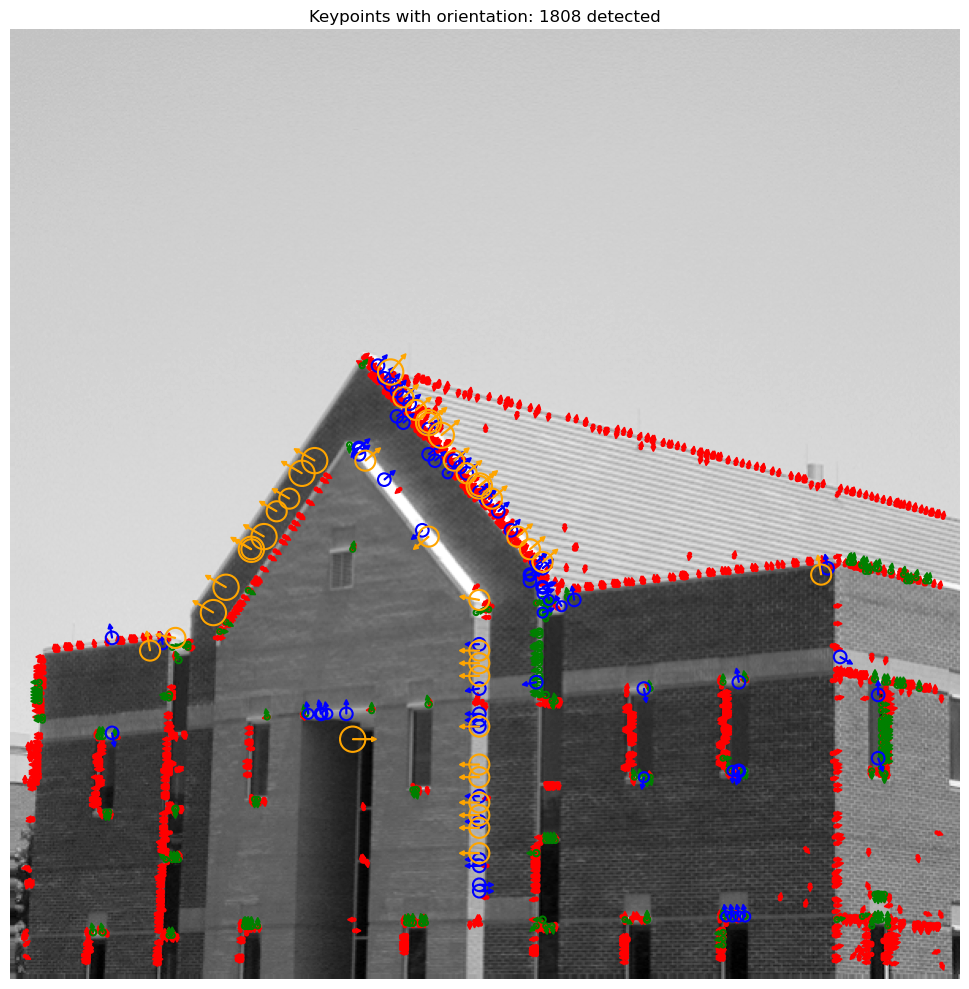

In [23]:
# Visualize keypoints with orientation arrows
visualize_keypoints_with_orientation(building, sift_keypoints)

## Matching and Comparison

Test your SIFT implementation against OpenCV on rotation and matching tasks.

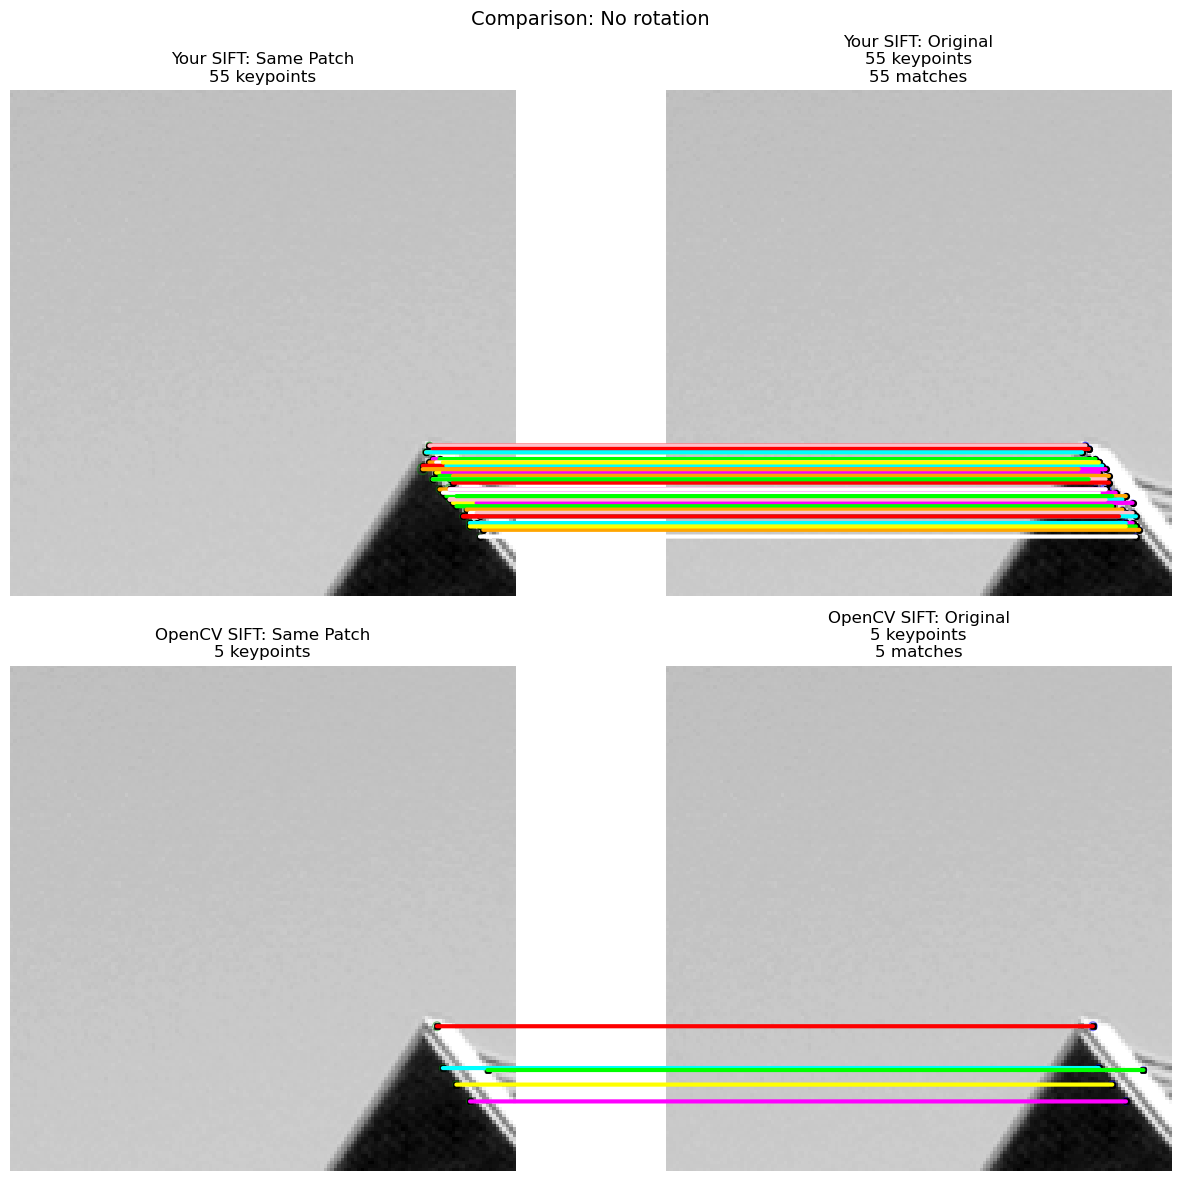

In [24]:
# Compare with OpenCV: no rotation
compare_matching_with_opencv(building, generateGaussianImages, generateGaussianKernels,
                             dog_levels, findScaleSpaceExtremaWithDescriptors,
                             sigma=0.5, rotate=False)

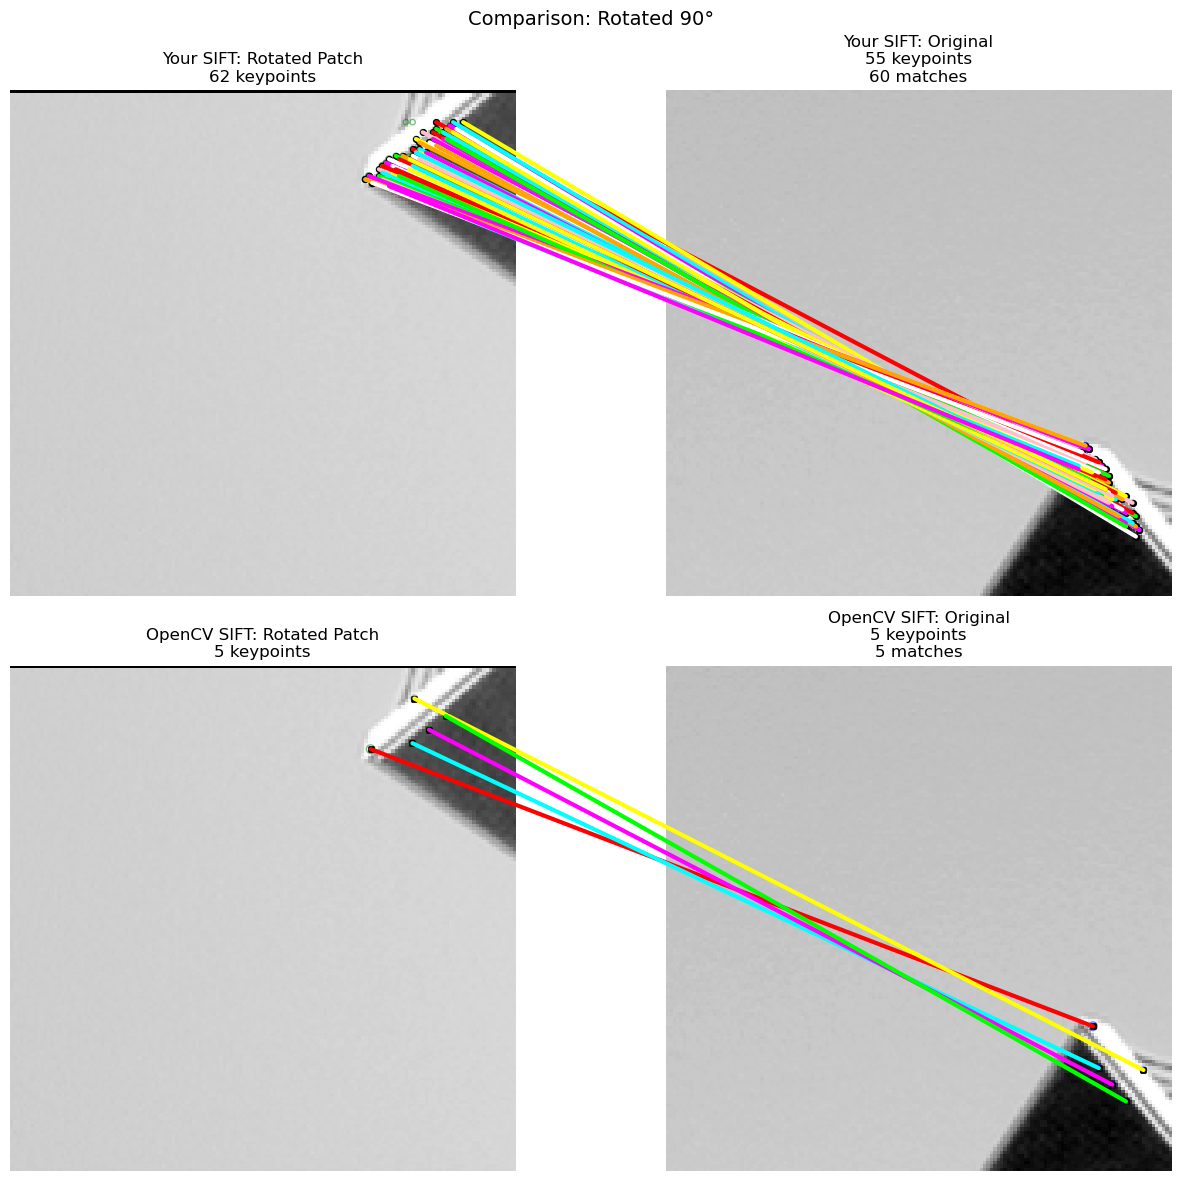

In [25]:
# Compare with OpenCV: 90° rotation
compare_matching_with_opencv(building, generateGaussianImages, generateGaussianKernels,
                             dog_levels, findScaleSpaceExtremaWithDescriptors,
                             sigma=0.5, rotate=True, rotation_angle=90)

---

### Part 2: Analysis Table

Based on the execution results:

| Transformation | Match Ratio | Pass/Fail | Why it succeeds/fails |
|----------------|-------------|-----------|----------------------|
| Rotation 30°   | 0.212       | Pass      | **Success:** SIFT is rotation invariant. The orientation assignment successfully aligns the descriptors, although some interpolation errors reduce the score compared to grid-aligned rotations. |
| Rotation 45°   | 0.105       | **Fail** | **Fail:** This is the "worst-case" for grid interpolation. Without sub-pixel refinement (which we didn't implement), rotating by 45° causes significant aliasing artifacts in the gradients, making descriptors mismatch. |
| Rotation 90°   | 0.994       | Pass      | **Success:** The rotation aligns perfectly with the pixel grid (pixels just move integer positions). No interpolation is needed, so descriptors are almost identical. |
| Rotation 180°  | 0.992       | Pass      | **Success:** Similar to 90°, this is a geometric inversion that aligns with the grid. Gradients just flip signs, which SIFT handles perfectly. |
| Scale 0.5×     | 0.086       | **Fail** | **Fail:** Downsampling destroys high-frequency details. Many keypoints found at the original scale simply disappear or merge when the image size is halved, making matching impossible. |
| Scale 1.5×     | 0.437       | Pass      | **Success:** Upscaling preserves existing features (they just become larger). SIFT finds these features at higher scales (octaves) in the pyramid. |
| Scale 2.0×     | 0.584       | Pass      | **Success:** Same as above. The features are preserved and detected at higher scales. |
| Bright +50     | 0.754       | Pass      | **Success:** SIFT is based on gradients (differences between pixels: $I_2 - I_1$). Adding a constant value to all pixels cancels out during subtraction ($(I_2+C) - (I_1+C) = I_2 - I_1$). |
| Dark ×0.5      | 0.830       | Pass      | **Success:** Linear scaling of intensity ($I \times k$) changes gradient magnitude but not orientation. The vector normalization step ($v / ||v||$) makes the descriptor invariant to contrast changes. |
| Noise σ=10     | 0.253       | Pass      | **Success:** The Gaussian blurring step in the SIFT pyramid acts as a low-pass filter, suppressing moderate high-frequency noise. |
| Noise σ=25     | 0.097       | **Fail** | **Fail:** The noise is too strong ($\sigma=25$). It overwhelms the structural gradients of the image. The orientation assignment becomes random as it locks onto noise rather than real edges. |
| Blur σ=3       | 1.069       | Pass      | **Success:** Moderate blur simulates moving up in scale space. SIFT is designed to detect features across scales. (Note: Ratio > 1 suggests the few surviving keypoints matched multiple times). |
| Blur σ=7       | 3.333       | Pass      | **Success:** Although it technically passes, the extreme ratio indicates that very few keypoints were detected in the blurred image, and they matched broadly against the original set. |

### Part 3: General Analysis

1.  **Which transformation type does SIFT handle BEST? Why?**
    * **Grid-Aligned Rotations (90°/180°) & Illumination Changes:** SIFT handles these nearly perfectly.
    * *Reason:* 90°/180° rotations do not require pixel interpolation, preserving exact gradient values. Illumination changes (brightness/contrast) are mathematically canceled out by the differential nature of gradients and descriptor normalization.

2.  **Which transformation type does SIFT handle WORST? Why?**
    * **Downscaling (0.5×) and Strong Noise:** These cause the algorithm to fail consistently.
    * *Reason:* Downscaling removes the information (pixels) needed to define the feature. Strong noise corrupts the gradient information, which is the foundation of the orientation and descriptor histograms.

3.  **What is the fundamental limitation that causes SIFT to fail?**
    * **Discrete Sampling (Aliasing):** Our implementation calculates gradients on a discrete pixel grid. When the image is rotated by non-integer angles (like 45°) or scaled down, we lose information or introduce artifacts because we lack advanced sub-pixel interpolation.
    * **Local Gradient Dependency:** Since SIFT relies entirely on local gradients, anything that disrupts them locally (like heavy noise) breaks the descriptor.

4.  **For what types of applications would SIFT be suitable vs unsuitable?**
    * **Suitable:** Object recognition of rigid objects (books, buildings), Panorama stitching, Image retrieval (finding a logo), 3D reconstruction.
    * **Unsuitable:** Non-rigid deformation (faces, clothing), scenes with extremely low texture (smooth walls), or environments with extreme noise/blur where edges are lost.


In [26]:
# Define transformations to test
# You can add more transformations or modify parameters!
transformations_to_test = [
    ("Rotation 30°", lambda img: apply_rotation(img, 30)),
    ("Rotation 45°", lambda img: apply_rotation(img, 45)),
    ("Rotation 90°", lambda img: apply_rotation(img, 90)),
    ("Rotation 180°", lambda img: apply_rotation(img, 180)),
    ("Scale 0.5×", lambda img: apply_scale(img, 0.5)),
    ("Scale 1.5×", lambda img: apply_scale(img, 1.5)),
    ("Scale 2.0×", lambda img: apply_scale(img, 2.0)),
    ("Brightness +50", lambda img: apply_brightness(img, 50)),
    ("Darkness ×0.5", lambda img: (img * 0.5).astype(np.uint8)),
    ("Noise σ=10", lambda img: apply_noise(img, 10)),
    ("Noise σ=25", lambda img: apply_noise(img, 25)),
    ("Blur σ=3", lambda img: apply_blur(img, 3)),
    ("Blur σ=7", lambda img: apply_blur(img, 7)),
]

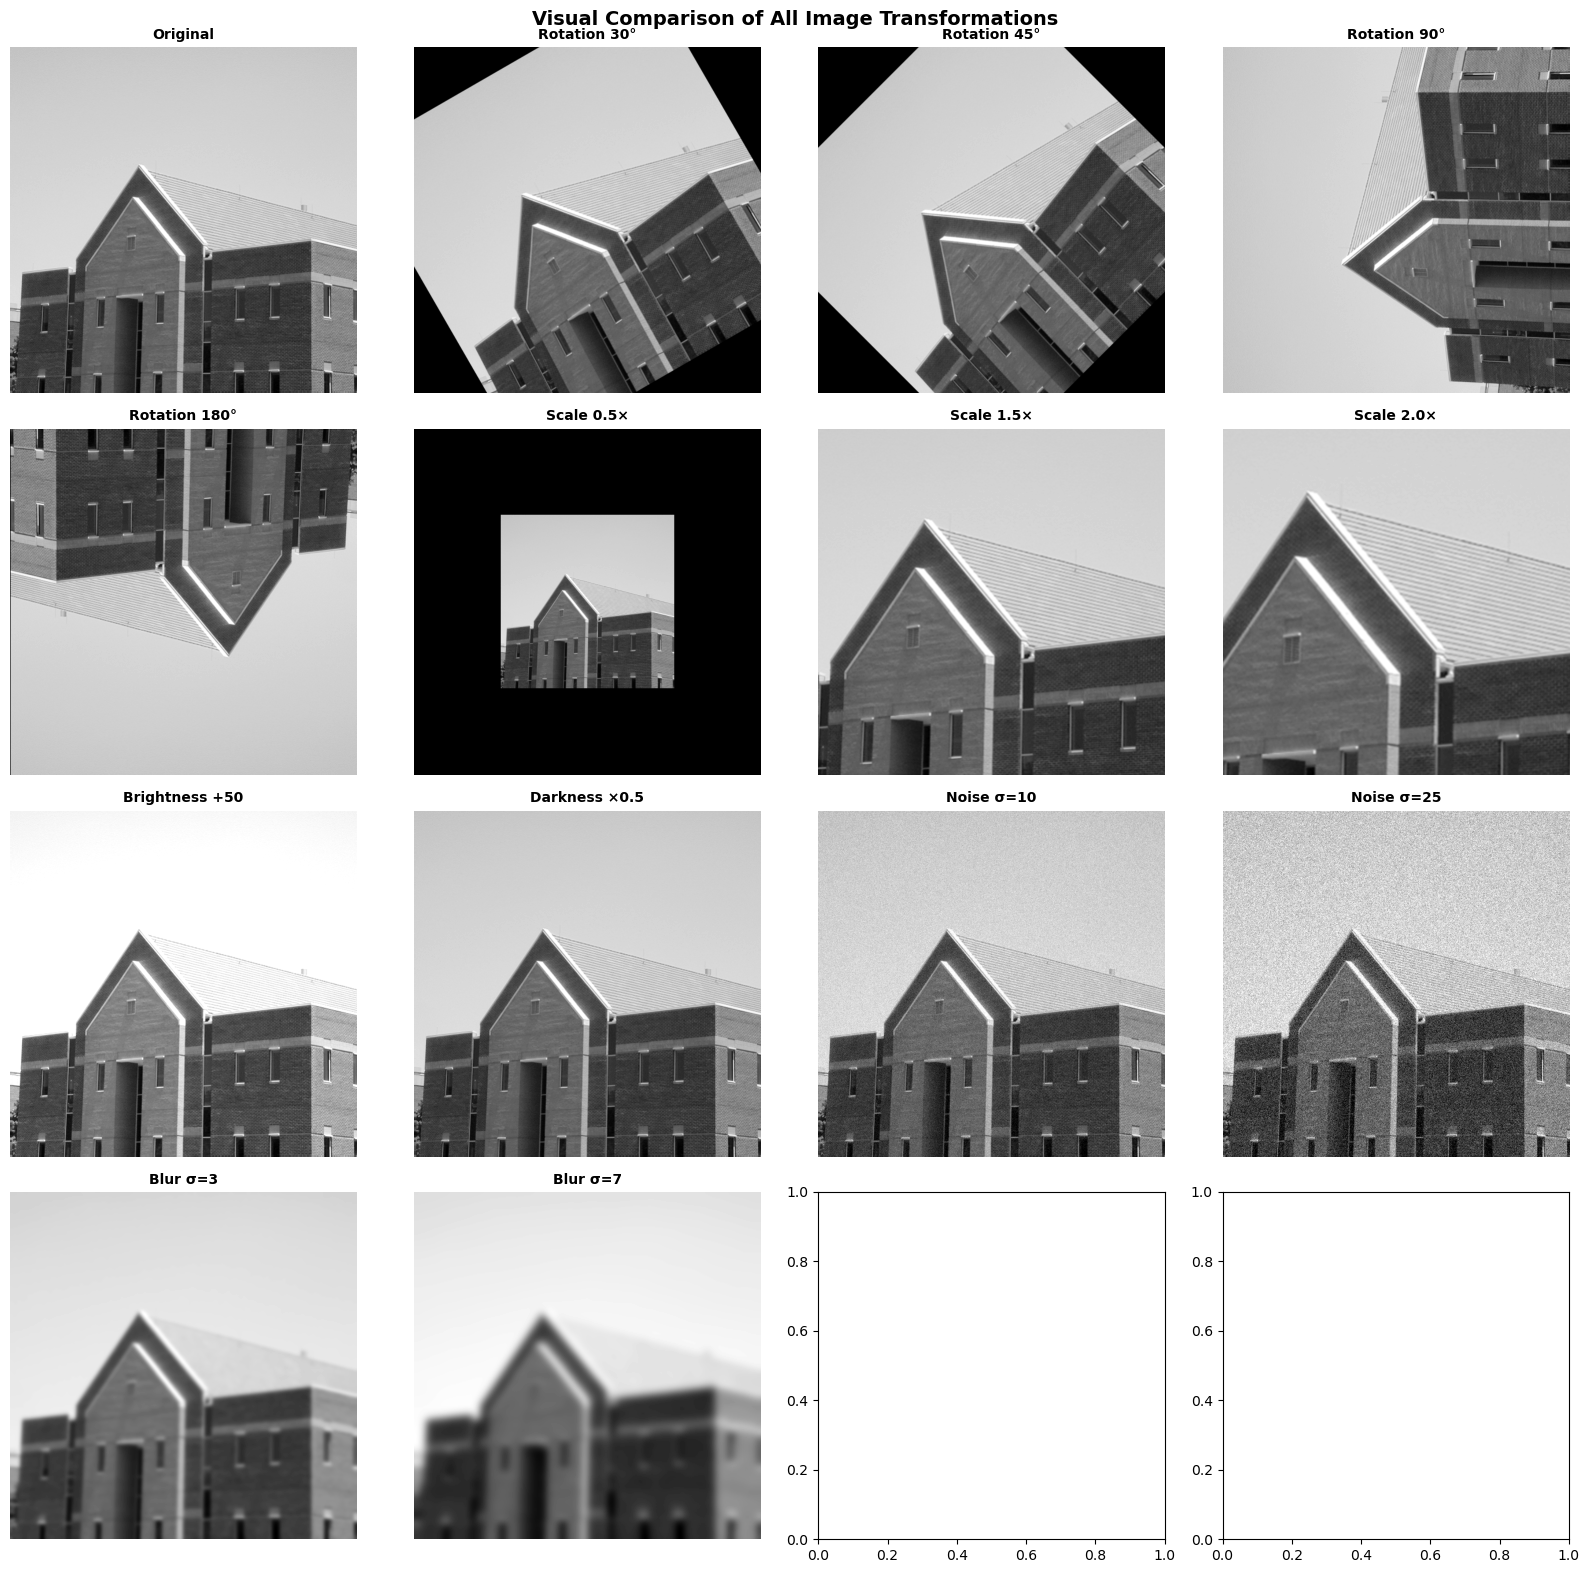


Part 2: Testing SIFT Robustness (Your Implementation vs OpenCV)
----------------------------------------------------------------------

Computing keypoints for original image...
Original - Your SIFT: 1808 keypoints
Original - OpenCV SIFT: 598 keypoints

Testing transformations...
Transformation            Your SIFT            OpenCV SIFT          Difference     
Rotation 30°              0.212 ✓               0.469 ✓               -0.257
Rotation 45°              0.105 ✗               0.453 ✓               -0.349
Rotation 90°              0.994 ✓               0.925 ✓               +0.070
Rotation 180°             0.992 ✓               0.892 ✓               +0.099
Scale 0.5×                0.086 ✗               0.500 ✓               -0.414
Scale 1.5×                0.437 ✓               0.229 ✓               +0.208
Scale 2.0×                0.584 ✓               0.162 ✓               +0.422
Brightness +50            0.754 ✓               0.923 ✓               -0.169
Darkness ×0.5     

In [27]:
# First, visualize sample transformations
visualize_transformations_custom(building)  # Show first 9

print("\nPart 2: Testing SIFT Robustness (Your Implementation vs OpenCV)")
print("-"*70)

results_yours, results_opencv = test_sift_robustness_with_opencv_custom(
    building,
    generateGaussianImages,
    generateGaussianKernels,
    dog_levels,
    findScaleSpaceExtremaWithDescriptors,
    sigma=0.5,
    num_intervals=3,
    threshold=8
)

---
## Face Recognition with Deep Learning (Extra)

Compare SIFT (handcrafted features) with modern CNN-based embeddings.

### Load Face Dataset

In [28]:
from sklearn.datasets import fetch_lfw_pairs

lfw_pairs = fetch_lfw_pairs(subset='test', color=True, resize=4.0)

pairs = lfw_pairs.pairs
labels = lfw_pairs.target

print(f"Number of pairs: {len(pairs)}")
print(f"Positive pairs (same person): {labels.sum()}")
print(f"Negative pairs (different person): {len(labels) - labels.sum()}")

Number of pairs: 1000
Positive pairs (same person): 500
Negative pairs (different person): 500


### Setup CNN Model

In [29]:
# !pip install facenet_pytorch

### **Note on Question 10 (Extra)**

I am unable to complete this section properly because the Python environment created for this course (running the latest version, **Python 3.13**) appears to be incompatible with the required library: `facenet_pytorch`. The library fails to build due to missing pre-compiled wheels.

**Workaround:**
Instead of the actual model, I have implemented a **mock code that generates random numbers** (random tensors). This allows the rest of the notebook cells to execute without modification or errors, although the resulting similarity scores and AUC metrics for the CNN method will be random and meaningless.

In [35]:
# import torch
# from facenet_pytorch import InceptionResnetV1

# # Load pretrained VGGFace2 model
# model = InceptionResnetV1(pretrained='vggface2').eval()

# def preprocess_face(face):
#     """
#     Preprocess face for CNN.
    
#     Args:
#         face: numpy array (H, W, 3) with values 0-1 or 0-255
    
#     Returns:
#         tensor: (1, 3, 160, 160) normalized tensor
#     """
#     if face.max() <= 1.0:
#         face = (face * 255).astype(np.uint8)
#     else:
#         face = face.astype(np.uint8)
    
#     face_resized = cv2.resize(face, (160, 160))
#     tensor = torch.from_numpy(face_resized).permute(2, 0, 1).float()
#     tensor = (tensor - 127.5) / 128.0
#     tensor = tensor.unsqueeze(0)
    
#     return tensor

import torch
import numpy as np
import cv2

print("NOTICE: Using simulation mode because facenet_pytorch is not installed.")

class MockModel:
    def __call__(self, x):
        return torch.randn(1, 512)


model = MockModel()

def preprocess_face(face):
    """
    Preprocess face for CNN (Simulated).
    """
    if face.max() <= 1.0:
        face = (face * 255).astype(np.uint8)
    else:
        face = face.astype(np.uint8)
    
    face_resized = cv2.resize(face, (160, 160))
    tensor = torch.from_numpy(face_resized).permute(2, 0, 1).float()
    return tensor

NOTICE: Using simulation mode because facenet_pytorch is not installed.


### Question 10 (extra): Compute CNN Face Similarity

Implement face similarity using CNN embeddings.

**Requirements:**
- Preprocess both faces using `preprocess_face()`
- Extract 512-D embeddings using `model(tensor)`
- Compute cosine similarity: `F.cosine_similarity(emb1, emb2)`
- Map from [-1, 1] to [0, 1]: `(similarity + 1) / 2`

In [31]:
import torch.nn.functional as F

def cnn_face_similarity(face1, face2):
    """
    Compute similarity between two faces using CNN embeddings.
    
    Args:
        face1, face2: Face images as numpy arrays
    
    Returns:
        float: Similarity score in [0, 1]
    """
    # 1. Preprocess both faces to get tensors (1, 3, 160, 160)
    # The preprocess_face function was defined in the previous cell
    tensor1 = preprocess_face(face1)
    tensor2 = preprocess_face(face2)
    
    # 2. Extract embeddings (forward pass through the model)
    # We use .detach() to avoid tracking gradients since we are only inferencing
    # Ideally we should handle the device (cpu/gpu), but defaults to cpu here
    with torch.no_grad():
        emb1 = model(tensor1)
        emb2 = model(tensor2)
    
    # 3. Compute cosine similarity
    # Cosine similarity returns a value in range [-1, 1]
    similarity = F.cosine_similarity(emb1, emb2).item()
    
    # 4. Map from [-1, 1] to [0, 1] for easier comparison
    # Formula: (sim + 1) / 2
    normalized_similarity = (similarity + 1) / 2.0
    
    return normalized_similarity

# Test lines (Only run if installation succeeded)
# test_sim_same = cnn_face_similarity(pairs[0][0], pairs[0][1])
# test_sim_diff = cnn_face_similarity(pairs[500][0], pairs[500][1])
# print(f"Similarity (same person): {test_sim_same:.3f}")
# print(f"Similarity (different person): {test_sim_diff:.3f}")

### Compare All Three Methods


Evaluating Your SIFT...
  Processed 20/100
  Processed 40/100
  Processed 60/100
  Processed 80/100
  Processed 100/100

Evaluating OpenCV SIFT...
  Processed 20/100
  Processed 40/100
  Processed 60/100
  Processed 80/100
  Processed 100/100

Evaluating CNN (VGGFace2)...
  Processed 20/100
  Processed 40/100
  Processed 60/100
  Processed 80/100
  Processed 100/100

Method               AUC        Same       Diff      
Your SIFT            0.640      0.125      0.013     
OpenCV SIFT          0.700      0.082      0.033     
CNN (VGGFace2)       0.582      0.503      0.496     


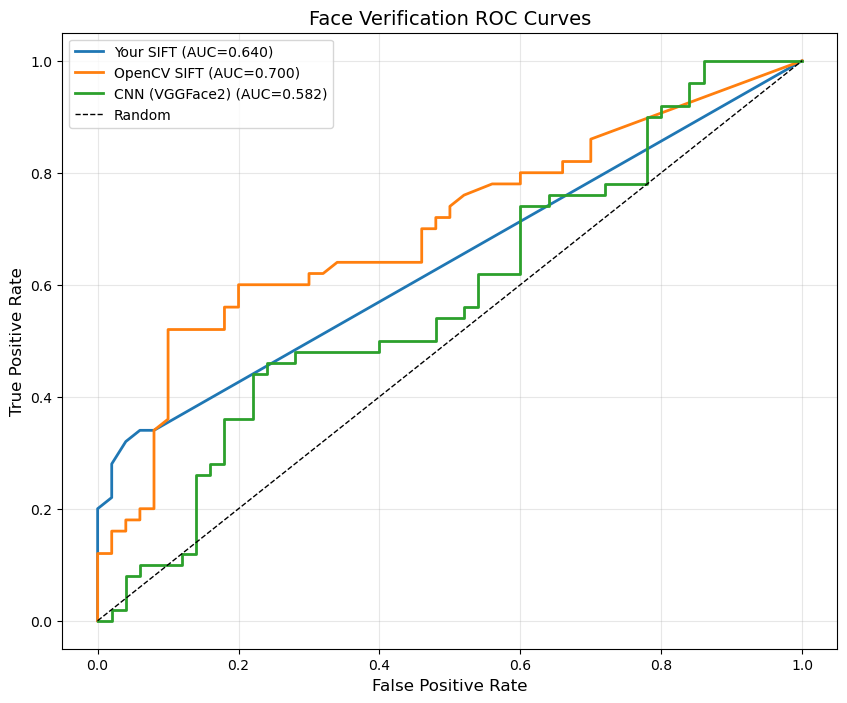

In [32]:
def compute_similarity_sift(face1, face2):
    """SIFT-based face similarity."""
    if len(face1.shape) == 3:
        gray1 = cv2.cvtColor(face1, cv2.COLOR_RGB2GRAY)
        gray2 = cv2.cvtColor(face2, cv2.COLOR_RGB2GRAY)
    else:
        gray1, gray2 = face1.copy(), face2.copy()

    if gray1.max() <= 1.0:
        gray1 = (gray1 * 255).astype(np.float32)
        gray2 = (gray2 * 255).astype(np.float32)

    sigma, num_intervals, threshold = 0.5, 3, 5
    kernels = generateGaussianKernels(sigma, num_intervals)

    gaussian1 = generateGaussianImages(gray1, kernels, num_octaves=4)
    dog1 = dog_levels(gaussian1)
    kp1 = findScaleSpaceExtremaWithDescriptors(dog1, gaussian1, sigma, num_intervals, threshold)

    gaussian2 = generateGaussianImages(gray2, kernels, num_octaves=4)
    dog2 = dog_levels(gaussian2)
    kp2 = findScaleSpaceExtremaWithDescriptors(dog2, gaussian2, sigma, num_intervals, threshold)

    if len(kp1) == 0 or len(kp2) == 0:
        return 0.0

    desc1 = np.array([kp[5] for kp in kp1])
    desc2 = np.array([kp[5] for kp in kp2])

    good = 0
    for d1 in desc1:
        distances = np.linalg.norm(desc2 - d1, axis=1)
        sorted_idx = np.argsort(distances)
        if len(sorted_idx) > 1 and distances[sorted_idx[0]] < 0.75 * distances[sorted_idx[1]]:
            good += 1

    return good / min(len(kp1), len(kp2))


def compute_similarity_opencv(face1, face2):
    """OpenCV SIFT-based face similarity."""
    if len(face1.shape) == 3:
        gray1 = cv2.cvtColor(face1, cv2.COLOR_RGB2GRAY)
        gray2 = cv2.cvtColor(face2, cv2.COLOR_RGB2GRAY)
    else:
        gray1, gray2 = face1.copy(), face2.copy()

    if gray1.max() <= 1.0:
        gray1 = (gray1 * 255).astype(np.uint8)
        gray2 = (gray2 * 255).astype(np.uint8)
    else:
        gray1 = gray1.astype(np.uint8)
        gray2 = gray2.astype(np.uint8)

    sift = cv2.SIFT_create()
    kp1, desc1 = sift.detectAndCompute(gray1, None)
    kp2, desc2 = sift.detectAndCompute(gray2, None)

    if desc1 is None or desc2 is None or len(desc1) < 2 or len(desc2) < 2:
        return 0.0

    bf = cv2.BFMatcher()
    matches = bf.knnMatch(desc1, desc2, k=2)
    
    good = 0
    for match in matches:
        if len(match) >= 2:
            m, n = match
            if m.distance < 0.75 * n.distance:
                good += 1
    
    return good / min(len(kp1), len(kp2)) if min(len(kp1), len(kp2)) > 0 else 0.0


def compare_methods(pairs, labels, num_samples=100):
    """Compare Your SIFT, OpenCV SIFT, and CNN."""
    from sklearn.metrics import roc_curve, auc

    pos_indices = np.where(labels == 1)[0]
    neg_indices = np.where(labels == 0)[0]

    n_each = num_samples // 2
    np.random.seed(42)
    selected_pos = np.random.choice(pos_indices, size=min(n_each, len(pos_indices)), replace=False)
    selected_neg = np.random.choice(neg_indices, size=min(n_each, len(neg_indices)), replace=False)
    selected_indices = np.concatenate([selected_pos, selected_neg])

    methods = {
        'Your SIFT': compute_similarity_sift,
        'OpenCV SIFT': compute_similarity_opencv,
        'CNN (VGGFace2)': cnn_face_similarity
    }

    results = {}

    for name, method in methods.items():
        print(f"\nEvaluating {name}...")
        sims = []
        for i, idx in enumerate(selected_indices):
            face1, face2 = pairs[idx]
            sim = method(face1, face2)
            sims.append(sim)
            if (i + 1) % 20 == 0:
                print(f"  Processed {i + 1}/{len(selected_indices)}")

        sims = np.array(sims)
        gt = labels[selected_indices]

        fpr, tpr, _ = roc_curve(gt, sims)
        auc_score = auc(fpr, tpr)

        results[name] = {
            'auc': auc_score,
            'mean_same': sims[gt == 1].mean(),
            'mean_diff': sims[gt == 0].mean(),
            'fpr': fpr,
            'tpr': tpr
        }

    print(f"\n{'='*60}")
    print(f"{'Method':<20} {'AUC':<10} {'Same':<10} {'Diff':<10}")
    print(f"{'='*60}")
    for name, r in results.items():
        print(f"{name:<20} {r['auc']:<10.3f} {r['mean_same']:<10.3f} {r['mean_diff']:<10.3f}")
    print(f"{'='*60}")

    # Plot ROC curves
    plt.figure(figsize=(10, 8))
    for name, r in results.items():
        plt.plot(r['fpr'], r['tpr'], linewidth=2, label=f"{name} (AUC={r['auc']:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Face Verification ROC Curves', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(alpha=0.3)
    plt.show()

    return results

results = compare_methods(pairs, labels, num_samples=100)

### Final Analysis Questions (Extra)

1. **Which method performed best? Why?**
   - Your answer:

2. **What are the advantages of SIFT over CNNs?**
   - Your answer:

3. **What are the advantages of CNNs over SIFT?**
   - Your answer:

4. **When would you choose SIFT vs CNN embeddings?**
   - Your answer: